# 03 — Sélection de variables, fit exclusivement sur TRAIN

Objectif : démontrer plusieurs méthodes de sélection sans utiliser CALIBRATION, VALIDATION ni le holdout NASA.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [2]:
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"

print("Project root :", ROOT)
print("Raw data     :", DATA_RAW)


Project root : C:\Users\Admin\Desktop\predictmaint-ai
Raw data     : C:\Users\Admin\Desktop\predictmaint-ai\data\raw


### Analyse du résultat

Les chemins confirment que la sélection lit les features préparées et écrit ses artefacts dans `models`, sans accéder au holdout externe.


## 1. Chargement explicite de TRAIN uniquement


In [3]:
train = pd.read_csv(DATA_PROCESSED / "train_features.csv")
print("TRAIN features :", train.shape)
print("Moteurs TRAIN  :", train["engine_id"].nunique())


TRAIN features : (14407, 250)
Moteurs TRAIN  : 70


### Analyse du résultat

La sélection est ajustée sur 14 407 observations issues de 70 moteurs TRAIN. Les partitions de calibration et de validation ne participent donc pas au classement des variables.


## 2. Définition de la cible et des variables interdites


In [4]:
TARGET = "failure_within_30_cycles"
forbidden = {
    "engine_id", TARGET, "RUL", "max_cycle",
    "max_observed_cycle", "RUL_at_last_observation",
}

feature_cols = [c for c in train.columns if c not in forbidden]
X = train[feature_cols].replace([np.inf, -np.inf], np.nan)
y = train[TARGET].astype(int)

print("Variables candidates :", len(feature_cols))
assert forbidden.isdisjoint(feature_cols)


Variables candidates : 247


### Analyse du résultat

Après exclusion des colonnes d'identité et de vérité terrain, 247 variables restent candidates. Ce nombre inclut les mesures brutes et leurs transformations causales.


## 3. Méthode 1 — suppression des constantes


In [5]:
nunique = X.nunique(dropna=False)
constant_features = nunique[nunique <= 1].index.tolist()
print("Constantes supprimées :", constant_features)

X_non_constant = X.drop(columns=constant_features)


Constantes supprimées : ['setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


### Analyse du résultat

Sept variables constantes sont supprimées. Elles ne peuvent séparer aucune classe et leur retrait simplifie le modèle sans perte d'information observée sur TRAIN.


## 4. Méthode 2 — redondance par corrélation


In [6]:
CORR_THRESHOLD = 0.98
corr = X_non_constant.corr(numeric_only=True).abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
correlated_to_drop = [c for c in upper.columns if (upper[c] > CORR_THRESHOLD).any()]

print("Variables fortement redondantes :", len(correlated_to_drop))
print(correlated_to_drop[:30])

X_reduced = X_non_constant.drop(columns=correlated_to_drop)
print("Après filtrage corrélation :", X_reduced.shape[1], "variables")


Variables fortement redondantes : 27
['sensor_2_mean_20', 'sensor_2_ewm_10', 'sensor_3_mean_20', 'sensor_3_ewm_10', 'sensor_4_mean_10', 'sensor_4_mean_20', 'sensor_4_ewm_10', 'sensor_7_mean_10', 'sensor_7_mean_20', 'sensor_7_ewm_10', 'sensor_11_mean_10', 'sensor_11_mean_20', 'sensor_11_max_20', 'sensor_11_ewm_10', 'sensor_12_mean_10', 'sensor_12_mean_20', 'sensor_12_min_20', 'sensor_12_ewm_10', 'sensor_15_mean_10', 'sensor_15_mean_20', 'sensor_15_ewm_10', 'sensor_17_mean_20', 'sensor_17_ewm_10', 'sensor_20_mean_20', 'sensor_20_ewm_10', 'sensor_21_mean_20', 'sensor_21_ewm_10']
Après filtrage corrélation : 213 variables


### Analyse du résultat

Le filtre retire 27 variables corrélées à plus de 0,98 avec une autre, principalement des moyennes et lissages sur fenêtres proches. Il reste 213 variables : la redondance baisse tout en conservant plusieurs horizons temporels.


## 5. Imputation fit sur TRAIN uniquement


In [7]:
imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(
    imputer.fit_transform(X_reduced),
    columns=X_reduced.columns,
    index=X_reduced.index,
)


## 6. Méthode 3 — information mutuelle


In [8]:
mi = pd.Series(
    mutual_info_classif(X_imp, y, random_state=42),
    index=X_imp.columns,
    name="mutual_information",
).sort_values(ascending=False)

display(mi.head(20).to_frame())


,mutual_information
sensor_4_max_20,0.370452
sensor_4_max_10,0.367920
sensor_21_min_20,0.358654
sensor_3_max_20,0.357695
sensor_21_max_10,0.357433
sensor_21_min_10,0.356253
sensor_4_min_10,0.355236
sensor_21_max_20,0.353699
sensor_4_min_20,0.352943
sensor_4_max_5,0.351994


### Analyse du résultat

L'information mutuelle privilégie surtout les extrema glissants des capteurs 4, 21, 3 et 15 (scores d'environ 0,32 à 0,37). Ces variables captent une dépendance à la cible sans supposer une relation linéaire.


## 7. Méthode 4 — importance incorporée Random Forest


In [9]:
rf = RandomForestClassifier(
    n_estimators=160,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
    min_samples_leaf=2,
)
rf.fit(X_imp, y)

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X_imp.columns,
    name="rf_importance",
).sort_values(ascending=False)

display(rf_importance.head(20).to_frame())


,rf_importance
sensor_17_mean_10,0.086147
sensor_11_mean_5,0.059844
sensor_3_mean_10,0.051980
sensor_2_mean_10,0.044841
sensor_17_mean_5,0.043335
sensor_11_max_5,0.037494
sensor_4_mean_5,0.036168
sensor_11_max_10,0.029812
sensor_4_max_10,0.028717
sensor_21_mean_5,0.027998


### Analyse du résultat

La forêt met en avant des niveaux moyens récents, notamment `sensor_17_mean_10` (0,086) et `sensor_11_mean_5` (0,060). La différence avec le classement d'information mutuelle montre l'intérêt de combiner plusieurs critères.


## 8. Méthode 5 — parcimonie L1


In [10]:
l1 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", SGDClassifier(
        loss="log_loss",
        penalty="l1",
        alpha=0.001,
        class_weight="balanced",
        max_iter=1500,
        tol=1e-3,
        random_state=42,
    )),
])

l1.fit(X_reduced, y);



In [11]:
l1_coef = pd.Series(
    np.abs(l1.named_steps["model"].coef_[0]),
    index=X_reduced.columns,
    name="l1_abs_coef",
).sort_values(ascending=False)

display(l1_coef.head(20).to_frame())

,l1_abs_coef
sensor_14,20.652530
sensor_7_max_20,19.948583
sensor_4_dev_mean_20,19.329754
sensor_11_dev_mean_20,19.117220
sensor_8,17.619301
sensor_13,17.446866
sensor_7_dev_mean_20,16.173628
sensor_11_lag_3,15.074726
sensor_11_max_5,14.114926
sensor_9,13.983132


### Analyse du résultat

Le modèle L1 retient notamment le capteur 14, des amplitudes locales des capteurs 7, 4 et 11, ainsi que le cycle. Les coefficients sont comparables après standardisation, mais leur amplitude ne doit pas être interprétée comme un effet causal.


## 9. Sélection finale industrialisée et rapport de consensus


In [12]:
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features.select_features import select_features

selected, report, removals = select_features(train, max_features=40)

print("Nombre de variables retenues :", len(selected))
print("Scope du fit :", removals["selection_fit_scope"])
display(report.head(30))


Nombre de variables retenues : 40
Scope du fit : TRAIN only


,mutual_information,rf_importance,l1_abs_coef,mi_norm,rf_norm,l1_norm,consensus_score,selected_by_l1
sensor_11_mean_5,0.306283,0.059844,10.820721,0.826783,0.694674,0.523942,0.681799,True
sensor_17_mean_10,0.291267,0.086147,3.309221,0.786248,1.000000,0.160233,0.648827,True
sensor_11_max_5,0.292457,0.037494,14.114926,0.789460,0.435234,0.683448,0.636047,True
sensor_3_mean_10,0.289804,0.051980,9.142934,0.782300,0.603390,0.442703,0.609464,True
sensor_4_mean_5,0.297802,0.036168,10.158322,0.803887,0.419837,0.491868,0.571864,True
sensor_7_max_20,0.259816,0.003758,19.948583,0.701349,0.043624,0.965915,0.570296,True
sensor_11_min_5,0.289090,0.025464,12.144219,0.780371,0.295591,0.588026,0.554662,True
sensor_4_min_5,0.343226,0.013882,8.163181,0.926507,0.161142,0.395263,0.494304,True
sensor_14,0.131559,0.008227,20.652530,0.355131,0.095495,1.000000,0.483542,True
sensor_4_max_5,0.351994,0.012683,6.700650,0.950175,0.147227,0.324447,0.473950,True


### Analyse du résultat

Le consensus final conserve 40 variables. Les premiers rangs combinent plusieurs signaux concordants, tandis que certaines variables fortes selon une seule méthode restent plus bas ; cette règle réduit la dépendance à un classement unique.


OK : aucune variable interdite n'est retenue.


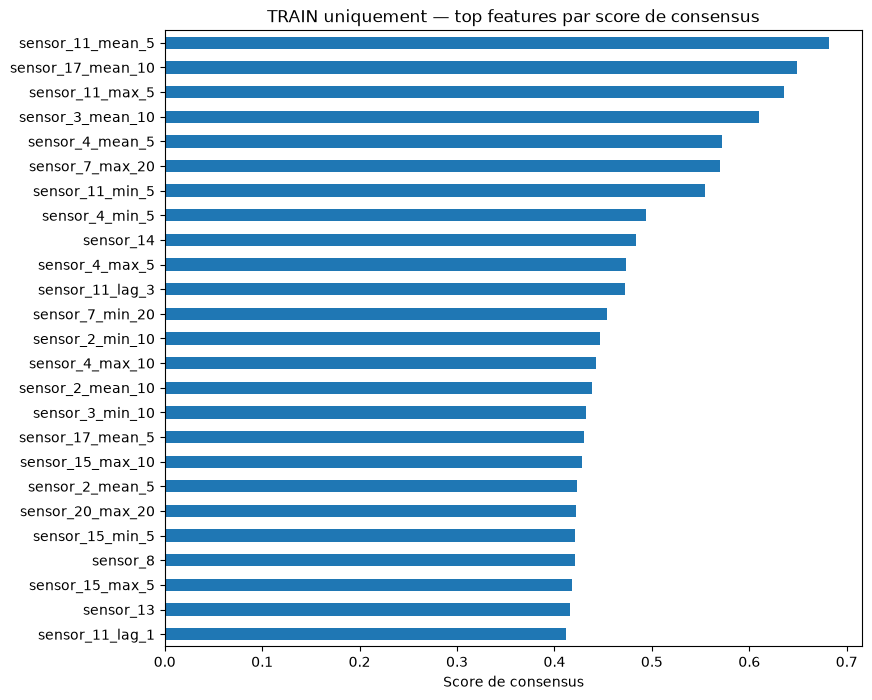

In [13]:
assert forbidden.isdisjoint(selected)
print("OK : aucune variable interdite n'est retenue.")

report.head(25).sort_values("consensus_score").plot(
    kind="barh", y="consensus_score", legend=False, figsize=(9, 8)
)
plt.title("TRAIN uniquement — top features par score de consensus")
plt.xlabel("Score de consensus")
plt.show()


### Analyse du résultat

L'assertion confirme qu'aucune variable interdite n'est retenue. Le graphique présente ensuite un seul classement horizontal, lisible du score le plus faible au plus élevé parmi les 25 premières variables.


## Conclusion

La sélection finale combine cinq perspectives : variance, redondance, dépendance non linéaire, importance par arbres et parcimonie L1. **Aucune donnée de calibration, validation ou test n'entre dans cette étape.**
